# Classificação de `Priority` — Technical Support Dataset

Construção de um classificador de `Priority` (`Low` / `Medium` / `High`) para tickets de suporte técnico. Continuação direta de `1.0-eda-technical-support-dataset.ipynb`.

**Caso de uso:** triagem — prever a prioridade de um ticket **no momento em que ele chega**, antes de qualquer atendimento. Essa restrição orienta toda a seleção de atributos abaixo: só entram no pipeline colunas que já existem quando o ticket é criado, para o modelo ser utilizável na prática (e para não introduzir vazamento de informação do futuro).

⚠️ **Este notebook lê `train.csv`/`val.csv`/`test.csv` de `data/processed/`, gerados por `priority_classification/modeling/dataset.py`.** Rode o script antes se esses arquivos não existirem.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from priority_classification.modeling.config import PROCESSED_DATA_DIR

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import LinearSVC

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Paleta categórica com ordem fixa (identidade da série nunca é ciclada por rank/posição)
CATEGORICAL_PALETTE = [
    "#2a78d6",  # blue
    "#eb6834",  # orange
    "#1baf7a",  # aqua
    "#eda100",  # yellow
    "#e87ba4",  # magenta
    "#008300",  # green
    "#4a3aa7",  # violet
    "#e34948",  # red
]

plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=CATEGORICAL_PALETTE),
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "grid.color": "#e1e0d9",
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "font.size": 11,
})

RANDOM_STATE = 42
PRIORITY_ORDER = ["Low", "Medium", "High"]

2026-08-23 11:56:17.176 | INFO     | priority_classification.modeling.config:<module>:11 - PROJ_ROOT path is: /home/caiobastos/Documentos/github/estudo_mentoria_caio_octavio/priority_classification


## 1. Carregamento dos dados

In [2]:
train_df = pd.read_csv(PROCESSED_DATA_DIR / "train.csv")
val_df = pd.read_csv(PROCESSED_DATA_DIR / "val.csv")
test_df = pd.read_csv(PROCESSED_DATA_DIR / "test.csv")

print(f"train: {train_df.shape} | val: {val_df.shape} | test: {test_df.shape}")
train_df.head()

train: (1631, 22) | val: (349, 22) | test: (350, 22)


,Status,Ticket ID,Priority,Source,Topic,Agent Group,Agent Name,Created time,Expected SLA to resolve,Expected SLA to first response,First response time,SLA For first response,Resolution time,SLA For Resolution,Close time,Agent interactions,Survey results,Product group,Support Level,Country,Latitude,Longitude
0,In progress,1013,High,Phone,Product setup,2nd line support,Adolpho Messingham,2023-01-02 07:27:25,2023-01-04 07:27:25,2023-01-02 07:29:25,2023-01-02 07:27:43.231,Within SLA,NaN,SLA Violated,NaN,3.0,NaN,Other,Tier 2,Italy,43.036776,12.678565
1,Resolved,1014,Low,Chat,Purchasing and invoicing,1st line support,Bernard Beckley,2023-01-02 06:59:04,2023-01-03 06:59:04,2023-01-02 07:01:04,2023-01-02 06:59:57.471,Within SLA,2023-01-02 22:45:32.974,Within SLA,NaN,2.0,NaN,Custom software development,Tier 1,Austria,47.696472,13.345735
2,Closed,1015,Medium,Email,Pricing and licensing,1st line support,Connor Danielovitch,2023-01-03 03:09:39,2023-01-05 03:09:39,2023-01-03 04:09:39,2023-01-03 07:09:15.835,SLA Violated,2023-01-04 14:32:34.979,Within SLA,2023-01-08 04:24:54.771,10.0,4.0,Ready to use Software,Tier 1,Spain,39.673370,-4.767726
3,Closed,1016,Low,Email,Product setup,1st line support,Kristos Westoll,2023-01-03 00:03:58,2023-01-05 00:03:58,2023-01-03 01:03:58,2023-01-03 00:08:01.684,Within SLA,2023-01-04 12:03:05.986,Within SLA,2023-01-06 06:05:08.637,1.0,2.0,Other,Tier 1,Austria,47.696472,13.345735
4,Closed,1017,Low,Email,Purchasing and invoicing,1st line support,Sheela Cutten,2023-01-03 14:25:42,2023-01-05 14:25:42,2023-01-03 15:25:42,2023-01-03 14:45:14.430,Within SLA,2023-01-04 01:55:56.533,Within SLA,2023-01-10 16:41:07.865,2.0,2.0,Ready to use Software,Tier 1,Greece,39.368279,21.863141


Checagem rápida (já esperada, dado como `modeling/dataset.py` estratifica o split): a distribuição de `Priority` deve ser praticamente igual nos três conjuntos.

In [3]:
split_dist = pd.DataFrame({
    "train": train_df["Priority"].value_counts(normalize=True),
    "val": val_df["Priority"].value_counts(normalize=True),
    "test": test_df["Priority"].value_counts(normalize=True),
}).reindex(PRIORITY_ORDER) * 100
print(split_dist.round(1))

max_gap = (split_dist.max(axis=1) - split_dist.min(axis=1)).max()
print(f"\nMaior gap entre splits, por classe: {max_gap:.1f} p.p.")

          train   val  test
Priority                   
Low        51.1  51.3  51.1
Medium     31.0  30.9  30.9
High       17.8  17.8  18.0

Maior gap entre splits, por classe: 0.2 p.p.


## 2. Quais atributos estão disponíveis na criação do ticket?

O objetivo é um classificador útil para **triagem**: prever `Priority` antes de qualquer atendimento. Isso exclui a maior parte das 22 colunas do dataset, que só passam a existir depois que o ticket já foi (parcialmente) tratado — usá-las seria vazamento de informação do futuro.

| Coluna(s) | Disponível na criação? | Decisão |
|---|---|---|
| `Source`, `Topic`, `Product group`, `Country`, `Created time` | Sim | **Usar** (`Topic` normalizando a duplicata de grafia encontrada em `1.0-eda-technical-support-dataset.ipynb`; `Created time` como dia da semana) |
| `Status` | Não, na prática | Excluir — todo ticket nasce `Open`; não varia no momento da criação |
| `Agent Group`, `Agent Name`, `Support Level` | Não | Excluir — atribuídos durante a triagem, potencialmente *decorrentes* de `Priority` (usar como feature seria vazamento circular); também redundantes entre si (achado do `1.0`) |
| `Expected SLA to resolve`, `Expected SLA to first response`, `First response time`, `SLA For first response`, `Resolution time`, `SLA For Resolution`, `Close time`, `Agent interactions`, `Survey results` | Não | Excluir — só existem conforme o ticket avança no atendimento |
| `Latitude`, `Longitude` | Redundante | Excluir — centróide fixo por `Country` (achado do `1.0`), não acrescenta nada além de `Country` |
| `Ticket ID` | N/A | Excluir — identificador, sem sinal preditivo |

Atributos finais candidatos: `Source`, `Topic` (normalizado), `Product group`, `Country`, dia da semana de `Created time`.

## 3. Há sinal nos atributos elegíveis? (treino)

Antes de montar qualquer pipeline, vale checar se esses 5 atributos carregam alguma associação real com `Priority` — caso contrário, não há razão para esperar que o classificador supere um baseline que ignora os atributos.

In [4]:
baseline_rate = train_df["Priority"].value_counts(normalize=True).reindex(PRIORITY_ORDER) * 100
print("Taxa base de Priority (treino):")
print(baseline_rate.round(1))


def priority_crosstab(data, col):
    """Proporção de cada Priority dentro de cada categoria de `col`."""
    ct = pd.crosstab(data[col], data["Priority"], normalize="index")
    return ct.reindex(columns=PRIORITY_ORDER).loc[data[col].value_counts().index]


def deviation_table(ct):
    """Desvio (em pontos percentuais) de cada célula em relação à taxa base."""
    return (ct * 100).sub(baseline_rate, axis=1)


def report_max_deviation(name, ct):
    max_dev = deviation_table(ct).abs().to_numpy().max()
    print(f"{name}: desvio máximo da taxa base = {max_dev:.1f} p.p. (n={len(ct)} categorias)")
    return max_dev


def plot_stacked_priority(ax, ct, title):
    left = np.zeros(len(ct))
    for priority, color in zip(PRIORITY_ORDER, CATEGORICAL_PALETTE):
        ax.barh(ct.index.astype(str), ct[priority], left=left, color=color, label=priority)
        left += ct[priority].to_numpy()
    ax.set_xlim(0, 1)
    ax.set_title(title)
    ax.set_xlabel("proporção")

Taxa base de Priority (treino):
Priority
Low       51.1
Medium    31.0
High      17.8
Name: proportion, dtype: float64


In [5]:
def prepare_features(data):
    """Normaliza `Topic` e deriva o dia da semana de `Created time`."""
    data = data.copy()
    data["Topic_norm"] = data["Topic"].str.lower()
    data["created_dow"] = pd.to_datetime(data["Created time"]).dt.day_name()
    return data


train_feat = prepare_features(train_df)

CANDIDATE_FEATURES = ["Source", "Topic_norm", "Product group", "Country", "created_dow"]

max_deviations = {}
for col in CANDIDATE_FEATURES:
    ct = priority_crosstab(train_feat, col)
    max_deviations[col] = report_max_deviation(col, ct)

Source: desvio máximo da taxa base = 4.3 p.p. (n=3 categorias)
Topic_norm: desvio máximo da taxa base = 6.7 p.p. (n=7 categorias)
Product group: desvio máximo da taxa base = 2.7 p.p. (n=4 categorias)
Country: desvio máximo da taxa base = 10.7 p.p. (n=12 categorias)


created_dow: desvio máximo da taxa base = 5.6 p.p. (n=7 categorias)


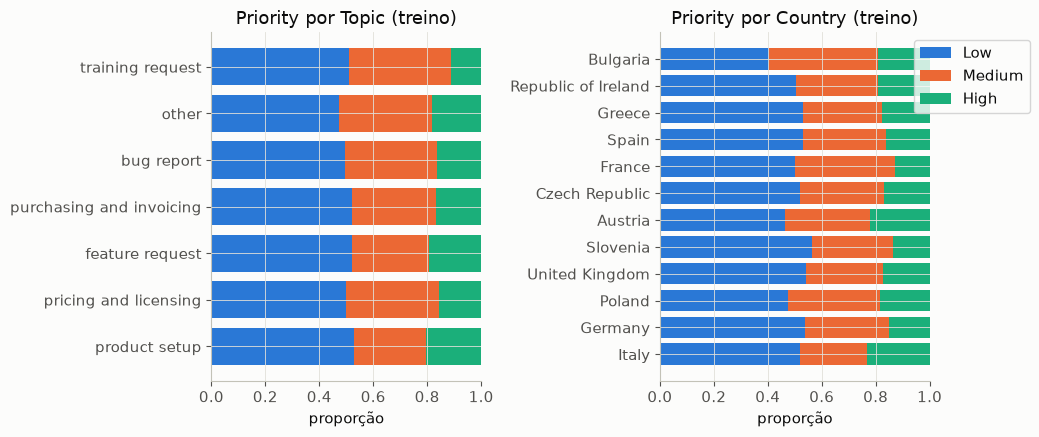

Ranking de desvio máximo da taxa base, por variável:
Country          10.7
Topic_norm        6.7
created_dow       5.6
Source            4.3
Product group     2.7
dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_stacked_priority(axes[0], priority_crosstab(train_feat, "Topic_norm"), "Priority por Topic (treino)")
plot_stacked_priority(axes[1], priority_crosstab(train_feat, "Country"), "Priority por Country (treino)")
axes[1].legend(loc="upper right", bbox_to_anchor=(1.4, 1))
plt.tight_layout()
plt.show()

print("Ranking de desvio máximo da taxa base, por variável:")
print(pd.Series(max_deviations).sort_values(ascending=False).round(1))

### Aside: cuidado com granularidade em `Created time`

Hora do dia tem 24 categorias — com ~1.630 tickets de treino isso dá só ~68 tickets por hora, pouco para estimar uma proporção com confiança. Comparando a hora bruta com um agrupamento mais largo (período do dia) mostra o efeito:

In [7]:
hour = pd.to_datetime(train_feat["Created time"]).dt.hour
hour_ct = priority_crosstab(train_feat.assign(created_hour=hour), "created_hour")
print(
    f"Hora bruta (24 buckets, ~{len(train_feat) // 24} tickets/bucket): "
    f"desvio máximo = {deviation_table(hour_ct).abs().to_numpy().max():.1f} p.p."
)

period = pd.cut(hour, bins=[-1, 5, 11, 17, 23], labels=["madrugada", "manhã", "tarde", "noite"])
period_ct = priority_crosstab(train_feat.assign(created_period=period), "created_period")
print(
    f"Período do dia (4 buckets, ~{len(train_feat) // 4} tickets/bucket): "
    f"desvio máximo = {deviation_table(period_ct).abs().to_numpy().max():.1f} p.p."
)

Hora bruta (24 buckets, ~67 tickets/bucket): desvio máximo = 14.4 p.p.
Período do dia (4 buckets, ~407 tickets/bucket): desvio máximo = 2.2 p.p.


O desvio de duas dígitos na hora bruta praticamente some ao agrupar em períodos mais largos — sinal de ruído amostral (poucos tickets por bucket), não de associação real. Por isso `Created time` entra no pipeline só como dia da semana (7 categorias, ~230 tickets cada), nunca como hora.

Voltando ao ranking da célula anterior: nenhum dos 5 atributos elegíveis passa de ~11 p.p. de desvio máximo, e os valores mais altos vêm de categorias com poucos tickets (`training request` em `Topic`, n=53; `Bulgaria` em `Country`, n=84) — mais consistente com ruído do que com sinal real. Ainda assim, seguimos para a modelagem: os 5 atributos entram no pipeline e deixamos os modelos (com regularização/`class_weight`) decidirem quanto peso dar a cada um; a comparação em `val.csv` na seção 6 mostra se isso supera o baseline.

## 4. Preparação de atributos

| Coluna(s) | Transformador | Motivo |
|---|---|---|
| `Source`, `Topic_norm`, `Product group`, `Country`, `created_dow` | `OneHotEncoder(handle_unknown="ignore")` | categóricas nominais, poucas categorias cada; `handle_unknown="ignore"` protege contra uma categoria aparecer em val/test mas não em treino |

In [8]:
val_feat = prepare_features(val_df)
test_feat = prepare_features(test_df)

X_train, y_train = train_feat[CANDIDATE_FEATURES], train_feat["Priority"]
X_val, y_val = val_feat[CANDIDATE_FEATURES], val_feat["Priority"]
X_test, y_test = test_feat[CANDIDATE_FEATURES], test_feat["Priority"]

preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), CANDIDATE_FEATURES)]
)

## 5. Baseline e candidatos de modelo

Baseline `DummyClassifier(strategy="stratified")` (respeita o balanceamento das classes sem usar nenhum atributo) contra três modelos padrão do `scikit-learn` (nenhuma dependência nova) que lidam bem com atributos categóricos esparsos via one-hot. `class_weight="balanced"` compensa o desbalanceamento de `Priority` (~51% `Low` / 31% `Medium` / 18% `High`).

In [9]:
candidates = {
    "Baseline (estratificado)": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Linear SVC": LinearSVC(class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE
    ),
}

pipelines = {
    name: Pipeline([("preprocessor", preprocessor), ("clf", clf)])
    for name, clf in candidates.items()
}

## 6. Seleção do modelo (comparação em `val.csv`)

Cada candidato é treinado em `train.csv` e avaliado em `val.csv`. Métrica principal: **macro-F1** (trata as 3 classes igualmente, ao contrário da accuracy — importante com `Low` a 51% dos tickets). Sem k-fold: já há um split fixo treino/val para esse fim; introduzir CV aqui só complicaria sem necessidade.

In [10]:
results = []
val_predictions = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    val_predictions[name] = y_pred
    results.append({
        "modelo": name,
        "accuracy": accuracy_score(y_val, y_pred),
        "macro_f1": f1_score(y_val, y_pred, average="macro"),
    })

results_df = pd.DataFrame(results).set_index("modelo").sort_values("macro_f1", ascending=False)
results_df.round(3)

,accuracy,macro_f1
modelo,,
Baseline (estratificado),0.370,0.317
Random Forest,0.350,0.303
Linear SVC,0.458,0.294
Logistic Regression,0.298,0.284


In [11]:
for name, y_pred in val_predictions.items():
    print(f"=== {name} ===")
    print(classification_report(y_val, y_pred, digits=3, zero_division=0))

=== Baseline (estratificado) ===
              precision    recall  f1-score   support

        High      0.149     0.177     0.162        62
         Low      0.486     0.486     0.486       179
      Medium      0.323     0.287     0.304       108

    accuracy                          0.370       349
   macro avg      0.319     0.317     0.317       349
weighted avg      0.376     0.370     0.372       349

=== Logistic Regression ===
              precision    recall  f1-score   support

        High      0.162     0.290     0.208        62
         Low      0.509     0.307     0.383       179
      Medium      0.238     0.287     0.261       108

    accuracy                          0.298       349
   macro avg      0.303     0.295     0.284       349
weighted avg      0.364     0.298     0.314       349

=== Linear SVC ===
              precision    recall  f1-score   support

        High      0.000     0.000     0.000        62
         Low      0.535     0.760     0.628      

In [12]:
winner_name = results_df.index[0]
print(
    f"Modelo vencedor (maior macro-F1 em val): {winner_name} "
    f"(macro-F1 = {results_df.loc[winner_name, 'macro_f1']:.3f})"
)

Modelo vencedor (maior macro-F1 em val): Baseline (estratificado) (macro-F1 = 0.317)


## 7. Avaliação final (`test.csv`)

`test.csv` é tocado **uma única vez**, aqui. O pipeline vencedor já foi treinado só em `train.csv` (seção 6, sem refit em treino+val) — mantendo a separação ajuste/comparação/avaliação-final.

Accuracy (test): 0.394
Macro-F1 (test): 0.339

              precision    recall  f1-score   support

        High      0.162     0.190     0.175        63
         Low      0.517     0.520     0.518       179
      Medium      0.344     0.306     0.324       108

    accuracy                          0.394       350
   macro avg      0.341     0.339     0.339       350
weighted avg      0.399     0.394     0.396       350



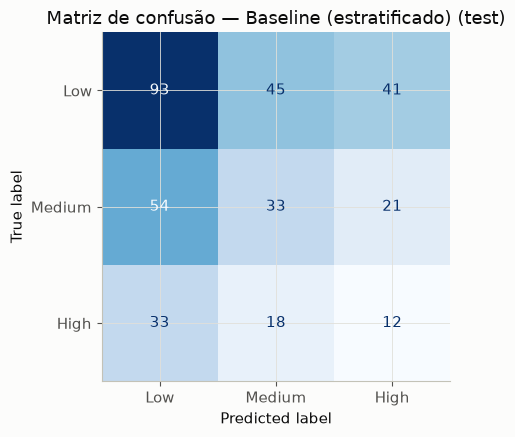

In [13]:
winner_pipeline = pipelines[winner_name]
y_test_pred = winner_pipeline.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_macro_f1 = f1_score(y_test, y_test_pred, average="macro")
print(f"Accuracy (test): {test_accuracy:.3f}")
print(f"Macro-F1 (test): {test_macro_f1:.3f}")
print()
print(classification_report(y_test, y_test_pred, digits=3, zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, labels=PRIORITY_ORDER, ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(f"Matriz de confusão — {winner_name} (test)")
plt.tight_layout()
plt.show()

## 8. O que mais pesa na decisão do modelo

Se o vencedor da seção 6 for o baseline (não expõe coeficientes/importâncias — ele ignora os atributos por definição), a análise abaixo cai para o melhor modelo *treinado* (maior macro-F1 entre os que de fato usam `X`), só para inspecionar o que ele aprendeu — mesmo sabendo que não superou o baseline em val.

Baseline (estratificado) não expõe coeficientes/importâncias (ignora os atributos por definição). Inspecionando o melhor modelo treinado em seu lugar: Random Forest (macro-F1 em val = 0.303, não superou o baseline).


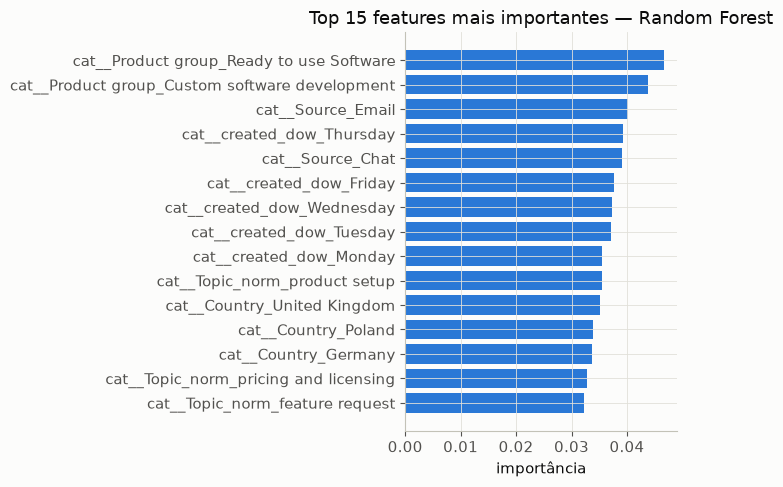

Top 15 respondem por 56.0% da importância total (33 features).


In [14]:
inspection_name = winner_name
inspection_pipeline = winner_pipeline
if not hasattr(inspection_pipeline.named_steps["clf"], "feature_importances_") and not hasattr(
    inspection_pipeline.named_steps["clf"], "coef_"
):
    inspection_name = results_df.drop(index=winner_name)["macro_f1"].idxmax()
    inspection_pipeline = pipelines[inspection_name]
    print(
        f"{winner_name} não expõe coeficientes/importâncias (ignora os atributos por definição). "
        f"Inspecionando o melhor modelo treinado em seu lugar: {inspection_name} "
        f"(macro-F1 em val = {results_df.loc[inspection_name, 'macro_f1']:.3f}, "
        f"não superou o baseline)."
    )

clf = inspection_pipeline.named_steps["clf"]
feature_names = inspection_pipeline.named_steps["preprocessor"].get_feature_names_out()

if hasattr(clf, "feature_importances_"):
    importances = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)
    top = importances.head(15)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(top.index[::-1], top.values[::-1], color=CATEGORICAL_PALETTE[0])
    ax.set_title(f"Top 15 features mais importantes — {inspection_name}")
    ax.set_xlabel("importância")
    plt.tight_layout()
    plt.show()
    print(f"Top 15 respondem por {top.sum() * 100:.1f}% da importância total ({len(feature_names)} features).")
elif hasattr(clf, "coef_"):
    coefs = pd.DataFrame(clf.coef_, index=clf.classes_, columns=feature_names)
    fig, axes = plt.subplots(1, len(clf.classes_), figsize=(4.5 * len(clf.classes_), 5), sharey=True)
    for ax, priority in zip(axes, clf.classes_):
        top = coefs.loc[priority].abs().sort_values(ascending=False).head(10)
        ax.barh(top.index[::-1], coefs.loc[priority, top.index[::-1]], color=CATEGORICAL_PALETTE[0])
        ax.set_title(priority)
    plt.tight_layout()
    plt.show()
else:
    print(f"{inspection_name} também não expõe coeficientes/importâncias diretamente.")

## 9. Resumo dos principais achados

- **Atributos elegíveis restritos:** das 22 colunas do dataset, só 5 estão disponíveis no momento de criação do ticket sem risco de vazamento (`Source`, `Topic`, `Product group`, `Country`, dia da semana) — o resto é atribuído durante o atendimento (agente, SLA, timestamps de resposta/resolução) ou é redundante (`Latitude`/`Longitude` vs. `Country`).
- **Sinal fraco em todos os atributos elegíveis:** nenhum passou de ~11 p.p. de desvio máximo da taxa base de `Priority`, e os maiores desvios vieram de categorias com poucas observações (`training request`, n=53; `Bulgaria`, n=84) — mais consistente com ruído amostral do que com associação real.
- **Cuidado com granularidade:** hora bruta de `Created time` (24 buckets) mostrou desvio de 14.4 p.p. que cai para 2.2 p.p. ao agrupar em períodos do dia mais largos — um lembrete de que buckets pequenos inflam desvios por acaso.
- **Nenhum modelo treinado superou o baseline aleatório em `val.csv`:** `Baseline (estratificado)` obteve macro-F1 = 0.317, contra 0.303 (Random Forest), 0.294 (Linear SVC) e 0.284 (Logistic Regression) — coerente com o sinal fraco encontrado na seção 3. O "vencedor" pela métrica é literalmente o modelo que ignora os atributos. Em `test.csv` o baseline ficou em macro-F1 = 0.339, accuracy = 0.394.
- **Conclusão prática:** com os atributos disponíveis na criação do ticket, este dataset não sustenta um classificador de `Priority` melhor do que sortear respeitando o balanceamento das classes. O gargalo é de **atributos**, não de escolha/ajuste de modelo.

## 10. Próximos passos

1. **Não promover nenhum destes modelos para produção como está** — nenhum bate o baseline; fazer isso seria pior do que não ter modelo algum.
2. **Buscar atributos com mais sinal antes de investir em modelagem adicional.** Este dataset não tem um campo de texto livre (como `Ticket Description` no dataset descartado); se houver uma versão com descrição do problema, repetir a checagem de sinal da seção 3 nela antes de assumir que ajuda. Vale também investigar se há um sistema de origem com mais contexto do ticket no momento da abertura.
3. **Se/quando um atributo com sinal real aparecer**, o pipeline desta seção (`ColumnTransformer` + `Pipeline`) já está pronto para receber novas colunas — promover para `priority_classification/modeling/train.py` e `predict.py` (ainda não existem — só `dataset.py`/`config.py` estão implementados hoje), seguindo o padrão Typer `app()` do resto do repositório.
4. **Registrar esta conclusão negativa** para não repetir a mesma tentativa (mesmos atributos, outros hiperparâmetros) esperando um resultado diferente.